# Stopword

## Import Library

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import string
import re
import langid

# Konfigurasi tampilan
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)

## Import Dataset

In [20]:
file_path = '../out/rawdata_spotify_id.csv'

df_spotify = pd.read_csv(file_path, low_memory=False)
print(f'✅ Dataset berhasil dimuat dari "{file_path}"')
display(df_spotify.head())

✅ Dataset berhasil dimuat dari "../out/rawdata_spotify_id.csv"


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terima kasih Spotify sudah menyediakan lagu_la...,5,0,NaN,2026-04-07 13:41:34,NaN,NaN,NaN
1,2c563637-cfe6-4dcc-9b2e-1e1ab3f3883a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN,9.1.32.2083
2,a5b1eaad-3605-4c20-b55a-1cb6bebeb857,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sebenarnya ini tuh udah bagus banget apknya cu...,4,0,NaN,2026-04-07 13:31:21,NaN,NaN,NaN
3,05c4415f-1a32-4b31-9f75-1c8b725f3e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN,NaN
4,d5236114-519c-4502-a94f-571f5d25a9eb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN,9.1.34.2060


In [21]:
df_spotify

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terima kasih Spotify sudah menyediakan lagu_la...,5,0,NaN,2026-04-07 13:41:34,NaN,NaN,NaN
1,2c563637-cfe6-4dcc-9b2e-1e1ab3f3883a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN,9.1.32.2083
2,a5b1eaad-3605-4c20-b55a-1cb6bebeb857,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sebenarnya ini tuh udah bagus banget apknya cu...,4,0,NaN,2026-04-07 13:31:21,NaN,NaN,NaN
3,05c4415f-1a32-4b31-9f75-1c8b725f3e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN,NaN
4,d5236114-519c-4502-a94f-571f5d25a9eb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN,9.1.34.2060
...,...,...,...,...,...,...,...,...,...,...,...
482751,ce6757d6-3ab0-43db-bbef-0fedd8e1c1d2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Angel lia,4,0,1.1.0.113,2014-06-11 07:54:42,NaN,NaN,1.1.0.113
482752,76bfc5ba-f552-42ea-ae62-9647d9158c6a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bayangan Dirimu,1,0,1.1.0.113,2014-06-07 15:06:50,NaN,NaN,1.1.0.113
482753,0e6a8c66-6990-47a3-a5f3-a070005682d8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,i like music,5,0,1.1.0.113,2014-06-06 15:06:13,NaN,NaN,1.1.0.113
482754,fe187b46-97ee-4d7a-ad56-b45bc2a6ecdb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Muzik My Life,5,0,1.1.0.113,2014-06-04 18:51:23,NaN,NaN,1.1.0.113


## Periksa Struktur Dataset

In [22]:
# Pemeriksaan tipe data dan nilai kosong pada setiap kolom
df_spotify.info()

<class 'pandas.DataFrame'>
RangeIndex: 482756 entries, 0 to 482755
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              482756 non-null  str  
 1   userName              482756 non-null  str  
 2   userImage             482756 non-null  str  
 3   content               482741 non-null  str  
 4   score                 482756 non-null  int64
 5   thumbsUpCount         482756 non-null  int64
 6   reviewCreatedVersion  326735 non-null  str  
 7   at                    482756 non-null  str  
 8   replyContent          4903 non-null    str  
 9   repliedAt             4903 non-null    str  
 10  appVersion            326735 non-null  str  
dtypes: int64(2), str(9)
memory usage: 40.5 MB


## Pengambilan Kolom Relevan

In [23]:
# Kolom seperti reviewId, userName, dan userImage
# tidak diperlukan dalam analisis sentimen

df_spotify.loc[:, ["content", "score", "thumbsUpCount",
                   "reviewCreatedVersion", "at",
                   "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,terima kasih Spotify sudah menyediakan lagu_la...,5,0,NaN,2026-04-07 13:41:34,NaN,NaN
1,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN
2,sebenarnya ini tuh udah bagus banget apknya cu...,4,0,NaN,2026-04-07 13:31:21,NaN,NaN
3,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN
4,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN
...,...,...,...,...,...,...,...
482751,Angel lia,4,0,1.1.0.113,2014-06-11 07:54:42,NaN,NaN
482752,Bayangan Dirimu,1,0,1.1.0.113,2014-06-07 15:06:50,NaN,NaN
482753,i like music,5,0,1.1.0.113,2014-06-06 15:06:13,NaN,NaN
482754,Muzik My Life,5,0,1.1.0.113,2014-06-04 18:51:23,NaN,NaN


## Inisiasi Stopwords

In [24]:
# Memuat daftar stopwords bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
indo_stopwords = set(factory.get_stop_words())

# Verifikasi jumlah stopwords
print(f'Total stopwords Sastrawi: {len(indo_stopwords)}')
print('\n20 stopwords pertama:')
print(list(indo_stopwords)[:20])

Total stopwords Sastrawi: 809

20 stopwords pertama:
['ditunjuknya', 'sebut', 'baru', 'c', 'tetapi', 'berawal', 'seberapa', 'seorang', 'terbanyak', 'terlebih', 'kamilah', 'akulah', 'jangan', 'sepanjang', 'perlukah', 'ataukah', 'sekurang-kurangnya', 'soalnya', 'bisa', 'disebutkan']


,Kata,Frekuensi
0,bagus,86127
1,lagu,73864
2,aplikasi,34172
3,spotify,30286
4,iklan,29408
...,...,...
95,love,2695
96,2,2668
97,akun,2663
98,tau,2630


/tmp/ipykernel_186353/4147612678.py:23: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/home/ergia/Documents/codes/pba-individu/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


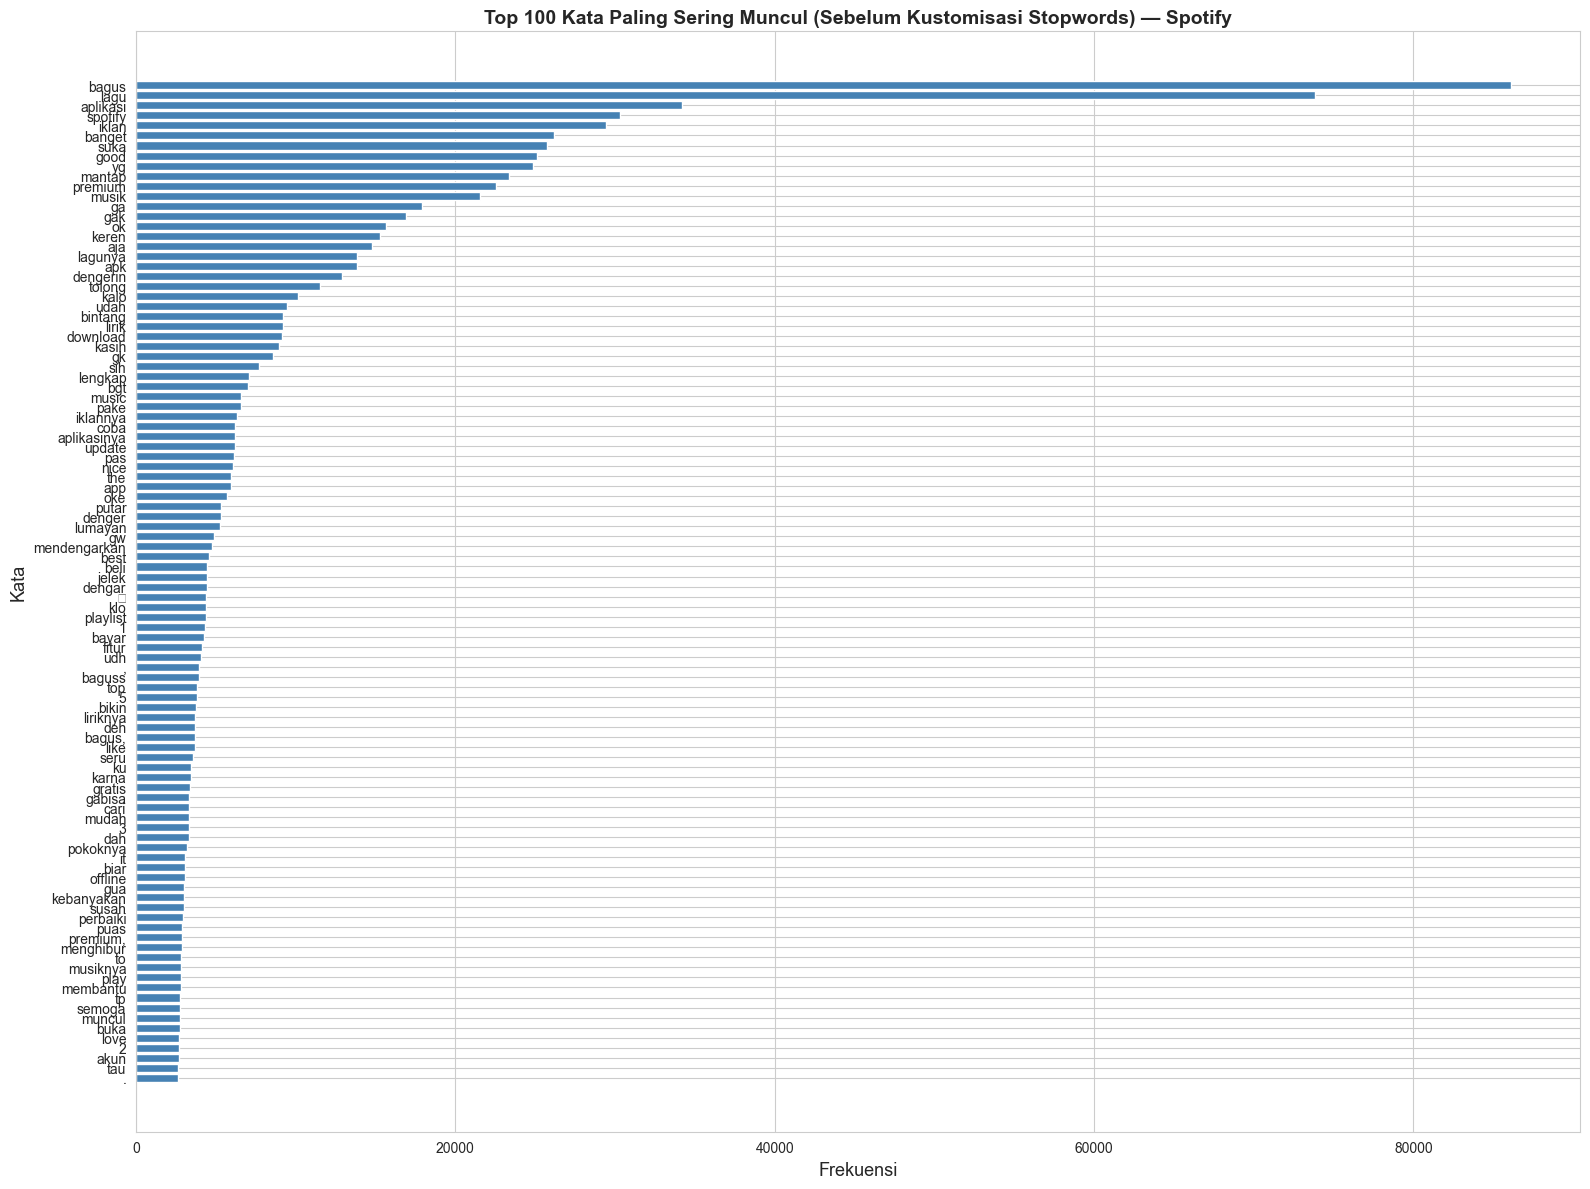

In [25]:
# Gabungkan seluruh teks ulasan menjadi satu string
semua_teks = ' '.join(df_spotify['content'].dropna().astype(str))

# Tokenisasi dan hapus stopwords Sastrawi
kata_semua = semua_teks.lower().split()
kata_terfilter = [kata for kata in kata_semua if kata not in indo_stopwords]

# Hitung frekuensi
frekuensi_kata = Counter(kata_terfilter)
kata_umum = frekuensi_kata.most_common(100)

# Konversi ke DataFrame
df_frekuensi = pd.DataFrame(kata_umum, columns=['Kata', 'Frekuensi'])
display(df_frekuensi)

# Visualisasi
plt.figure(figsize=(16, 12))
plt.barh(df_frekuensi['Kata'][::-1], df_frekuensi['Frekuensi'][::-1], color='steelblue')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata', fontsize=13)
plt.title('Top 100 Kata Paling Sering Muncul (Sebelum Kustomisasi Stopwords) — Spotify', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Kustomisasi Stopwords

In [26]:
# Kata-kata yang sering muncul namun tidak memiliki
# nilai sentimen ditambahkan ke dalam daftar stopwords

custom_stopwords = [
    # 1. Istilah domain aplikasi musik/streaming
    'aplikasi', 'spotify', 'app', 'fitur', 'musik', 'lagu',
    'playlist', 'album', 'artis', 'penyanyi', 'audio', 'suara',
    'streaming', 'download', 'offline', 'online', 'lirik',
    'premium', 'iklan', 'ads', 'free', 'gratis', 'langganan',
    'update', 'versi', 'instal', 'masuk', 'daftar', 'akun',

    # 2. Kata kerja & kata umum netral
    'bisa', 'mau', 'perlu', 'pakai', 'pake', 'dengar', 'denger',
    'putar', 'stel', 'coba', 'kasih', 'bilang', 'minta', 'lagi', 
    'udah', 'sudah', 'belum', 'kalau', 'kalo', 'ada', 'adalah', 
    'adanya', 'adapun', 'aja', 'banget', 'terlalu',

    # 3. Kata ganti & kata seru
    'saya', 'aku', 'gue', 'gw', 'kamu', 'anda',
    'nya', 'si', 'min', 'admin', 'kak', 'bang',
    'nih', 'tuh', 'aja', 'deh', 'dong', 'sih',
    'yah', 'wah', 'aduh', 'oke', 'ok', 'ya',

    # 4. Kata waktu & kuantitas
    'hari', 'minggu', 'bulan', 'tahun', 'lama',
    'cepat', 'kali', 'jam', 'menit', 'detik',
    'pertama', 'kedua', 'terakhir', 'sering', 'selalu',

    # 5. Simbol & residu tanda baca
    'amp', '&', '.', ',', '-', '!', '?', '...',
    '1', '2', '3', '4', '5',
]

# Gabungkan stopwords Sastrawi dengan custom stopwords
indo_stopwords.update(custom_stopwords)

print(f'Total stopwords setelah kustomisasi: {len(indo_stopwords)}')

Total stopwords setelah kustomisasi: 884


In [27]:
indo_stopwords

{'!',
 '&',
 ',',
 '-',
 '.',
 '...',
 '1',
 '2',
 '3',
 '4',
 '5',
 '?',
 'a',
 'ada',
 'adalah',
 'adanya',
 'adapun',
 'admin',
 'ads',
 'aduh',
 'agak',
 'agaknya',
 'agar',
 'aja',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'akun',
 'album',
 'amat',
 'amatlah',
 'amp',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'aplikasi',
 'app',
 'arti',
 'artinya',
 'artis',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'audio',
 'awal',
 'awalnya',
 'b',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagainamakah',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasannya',
 'bahwasanya',
 'baik',
 'baiklah',
 'bakal',
 'bakalan',
 'balik',
 'bang',
 'banget',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'be

## Analisis Hasil Pembersihan

=== TOP 100 KATA SETELAH PEMBERSIHAN ===
[('bagus', 86127), ('suka', 25732), ('good', 25084), ('mantap', 23343), ('gak', 16904), ('keren', 15266), ('lagunya', 13855), ('apk', 13827), ('dengerin', 12875), ('tolong', 11496), ('bintang', 9233), ('lengkap', 7050), ('bgt', 7035), ('music', 6594), ('iklannya', 6354), ('aplikasinya', 6207), ('pas', 6143), ('nice', 6058), ('the', 5977), ('lumayan', 5264), ('mendengarkan', 4744), ('best', 4539), ('beli', 4450), ('jelek', 4420), ('klo', 4376), ('bayar', 4255), ('udh', 4060), ('baguss', 3922), ('top', 3848), ('bikin', 3779), ('liriknya', 3705), ('bagus,', 3694), ('like', 3694), ('seru', 3563), ('karna', 3426), ('gabisa', 3344), ('cari', 3342), ('mudah', 3313), ('dah', 3293), ('pokoknya', 3175), ('biar', 3044), ('gua', 3033), ('kebanyakan', 3032), ('susah', 3008), ('perbaiki', 2911), ('puas', 2897), ('premium,', 2888), ('menghibur', 2854), ('musiknya', 2801), ('play', 2793), ('membantu', 2791), ('semoga', 2772), ('muncul', 2768), ('buka', 2736), (

,Kata,Frekuensi
0,bagus,86127
1,suka,25732
2,good,25084
3,mantap,23343
4,gak,16904
...,...,...
95,kikir,1808
96,bug,1792
97,kualitas,1792
98,kecewa,1792


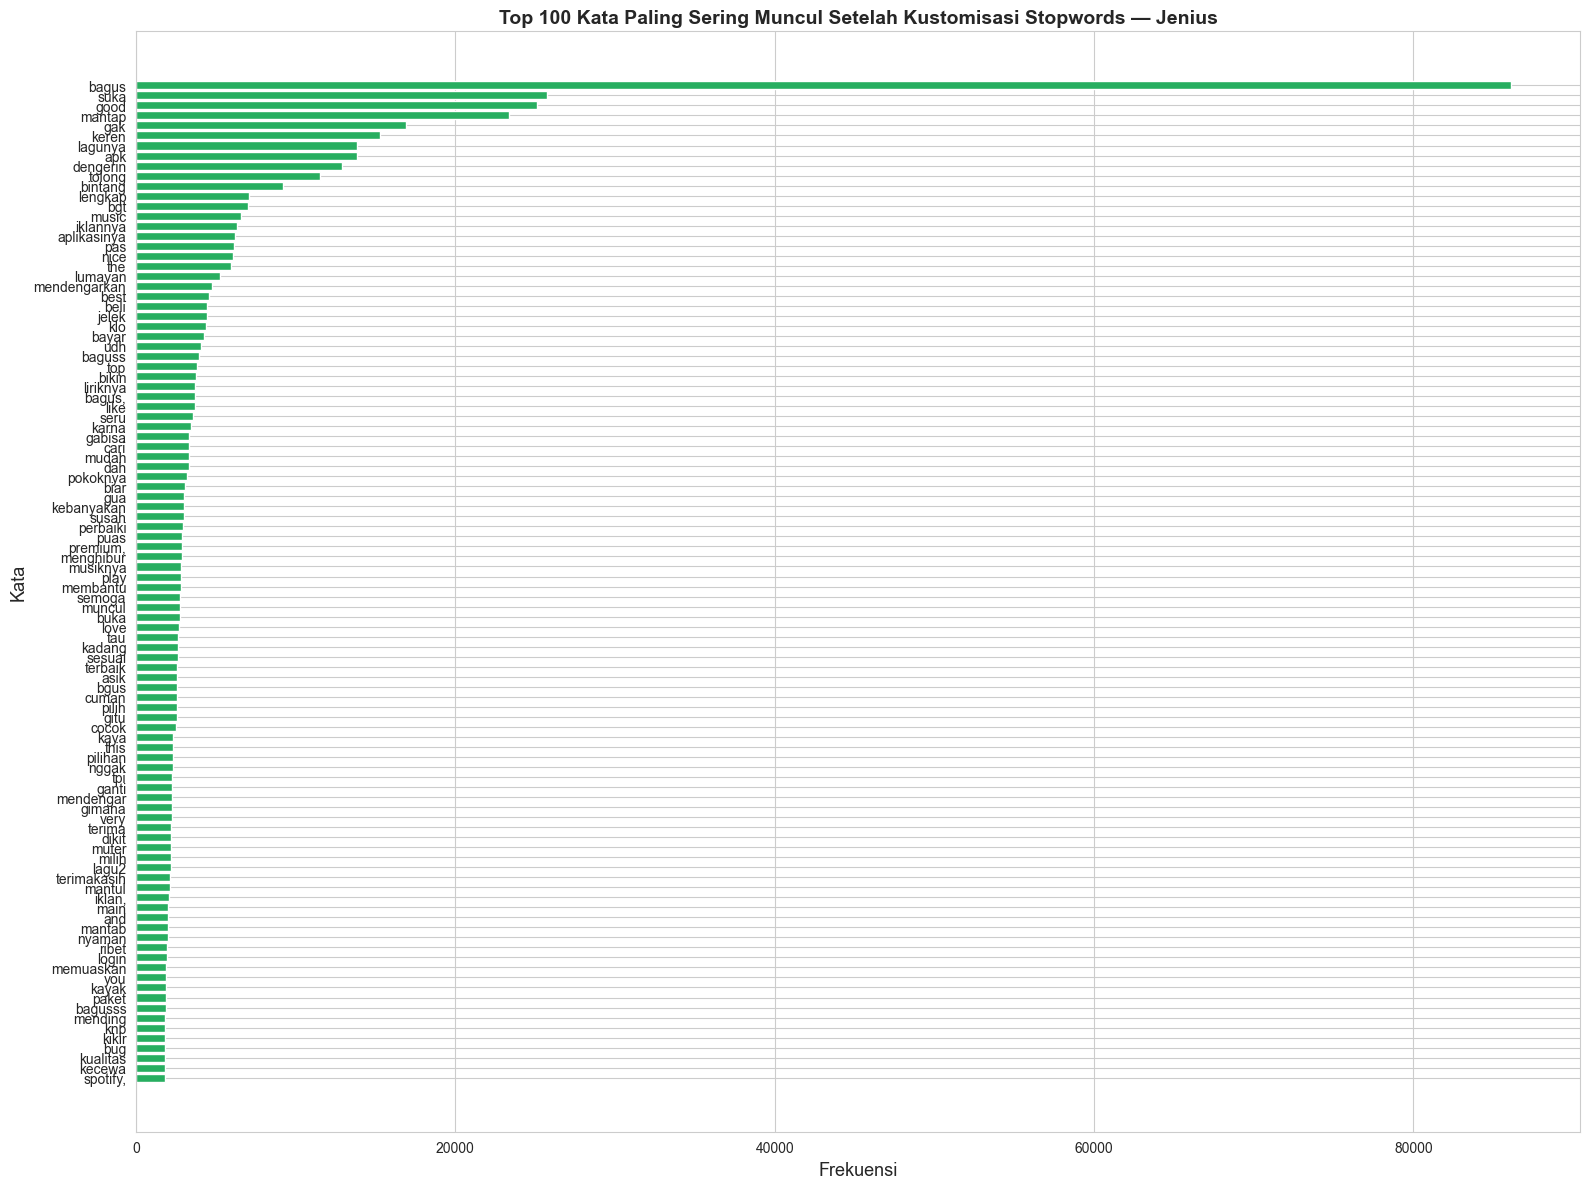

In [28]:
# Tokenisasi ulang dengan stopwords yang telah dikustomisasi
kata_bersih = [kata for kata in kata_semua if kata not in indo_stopwords and len(kata) > 2]

# Hitung frekuensi kata bersih
frekuensi_bersih = Counter(kata_bersih)
kata_umum_bersih = frekuensi_bersih.most_common(100)

# Konversi ke DataFrame
df_frekuensi_bersih = pd.DataFrame(kata_umum_bersih, columns=['Kata', 'Frekuensi'])

print('=== TOP 100 KATA SETELAH PEMBERSIHAN ===')
print(kata_umum_bersih)
display(df_frekuensi_bersih)

# Visualisasi
plt.figure(figsize=(16, 12))
plt.barh(df_frekuensi_bersih['Kata'][::-1], df_frekuensi_bersih['Frekuensi'][::-1],
         color='#27ae60', edgecolor='white')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata', fontsize=13)
plt.title('Top 100 Kata Paling Sering Muncul Setelah Kustomisasi Stopwords — Jenius',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stemming

,Kata Dasar,Frekuensi
0,bagus,95606
1,suka,31894
2,good,26797
3,mantap,25700
4,lagu,20456
5,,18253
6,keren,17250
7,gak,17086
8,apk,14256
9,dengerin,12992


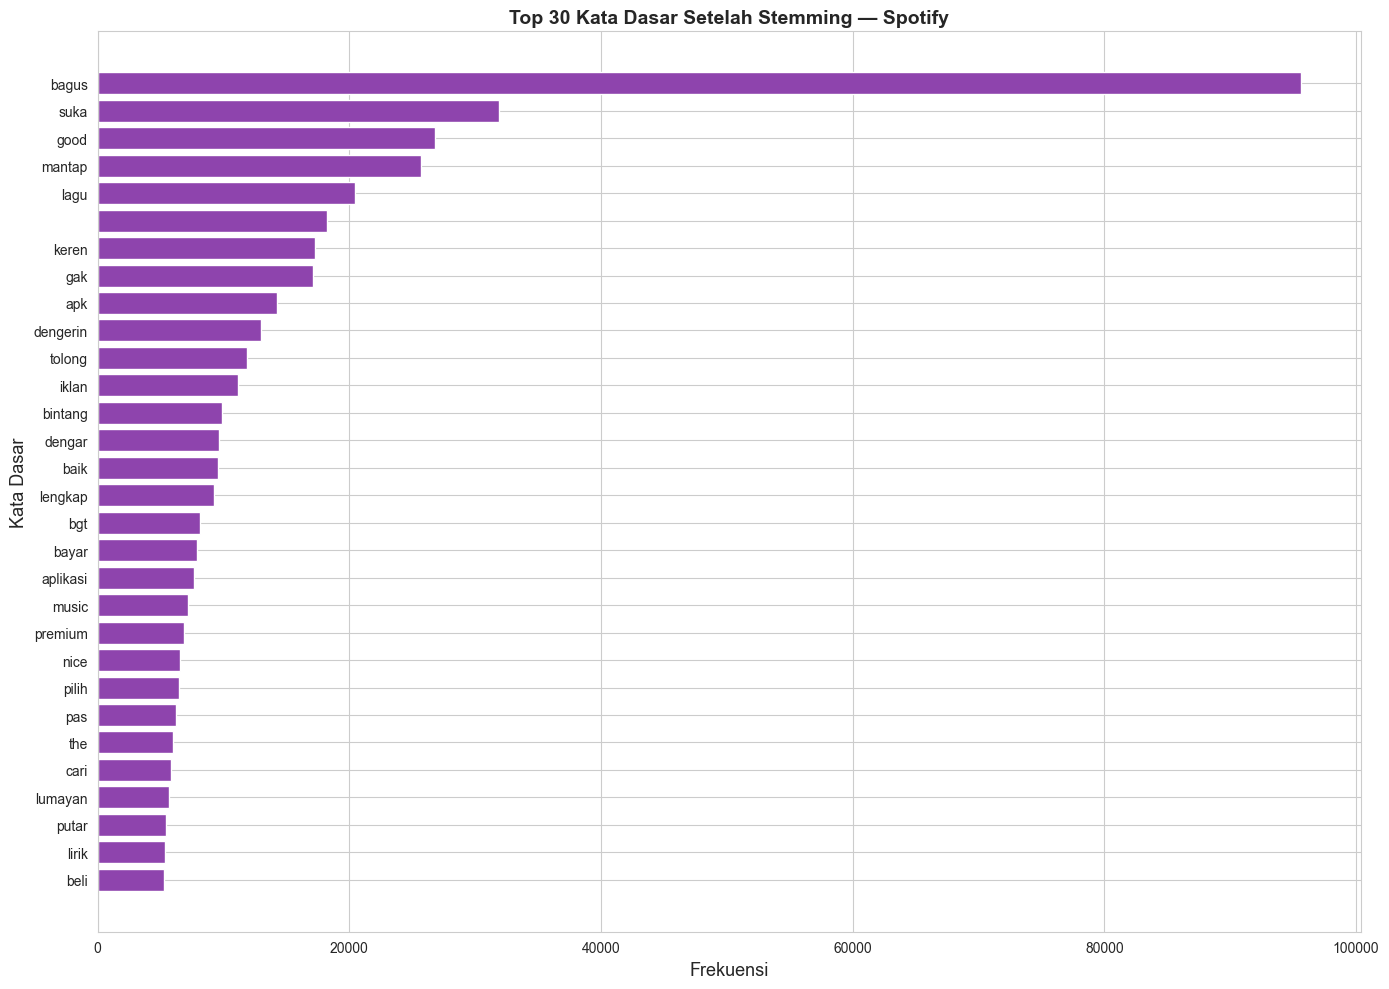

In [29]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# Stemming seluruh kata bersih
kata_stemmed = [stemmer.stem(kata) for kata in kata_bersih]

# Hitung frekuensi setelah stemming
frekuensi_stemmed = Counter(kata_stemmed)
kata_umum_stemmed = frekuensi_stemmed.most_common(100)

df_stemmed_freq = pd.DataFrame(kata_umum_stemmed, columns=['Kata Dasar', 'Frekuensi'])
display(df_stemmed_freq.head(20))

# Visualisasi top 30 kata dasar
top30 = df_stemmed_freq.head(30)
plt.figure(figsize=(14, 10))
plt.barh(top30['Kata Dasar'][::-1], top30['Frekuensi'][::-1],
         color='#8e44ad', edgecolor='white')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata Dasar', fontsize=13)
plt.title('Top 30 Kata Dasar Setelah Stemming — Spotify',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Preprocessing

## Konfigurasi tambahan untuk analisis sentimen dan visualisasi lanjutan

In [32]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

## Load Dataset

In [41]:
file_path = '../out/rawdata_spotify_id.csv'

df_spotify = pd.read_csv(file_path, low_memory=False)
print(f'✅ Dataset berhasil dimuat: {len(df_spotify):,} baris')
display(df_spotify.head())

✅ Dataset berhasil dimuat: 482,756 baris


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terima kasih Spotify sudah menyediakan lagu_la...,5,0,NaN,2026-04-07 13:41:34,NaN,NaN,NaN
1,2c563637-cfe6-4dcc-9b2e-1e1ab3f3883a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN,9.1.32.2083
2,a5b1eaad-3605-4c20-b55a-1cb6bebeb857,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sebenarnya ini tuh udah bagus banget apknya cu...,4,0,NaN,2026-04-07 13:31:21,NaN,NaN,NaN
3,05c4415f-1a32-4b31-9f75-1c8b725f3e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN,NaN
4,d5236114-519c-4502-a94f-571f5d25a9eb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN,9.1.34.2060


## Konversi Format Waktu

In [42]:
df_spotify['at'] = pd.to_datetime(df_spotify['at'])
df_spotify.info()

<class 'pandas.DataFrame'>
RangeIndex: 482756 entries, 0 to 482755
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              482756 non-null  str           
 1   userName              482756 non-null  str           
 2   userImage             482756 non-null  str           
 3   content               482741 non-null  str           
 4   score                 482756 non-null  int64         
 5   thumbsUpCount         482756 non-null  int64         
 6   reviewCreatedVersion  326735 non-null  str           
 7   at                    482756 non-null  datetime64[us]
 8   replyContent          4903 non-null    str           
 9   repliedAt             4903 non-null    str           
 10  appVersion            326735 non-null  str           
dtypes: datetime64[us](1), int64(2), str(8)
memory usage: 40.5 MB


## Hapus Kolom Ridak Relevan & Tangani Missing Values

In [43]:
#Cek missing values
df_spotify.isnull().sum()

reviewId                     0
userName                     0
userImage                    0
content                     15
score                        0
thumbsUpCount                0
reviewCreatedVersion    156021
at                           0
replyContent            477853
repliedAt               477853
appVersion              156021
dtype: int64

In [44]:
# Hapus kolom metadata yang tidak dibutuhkan dalam analisis sentimen
df_spotify = df_spotify.drop(columns=['userName', 'userImage'])

In [45]:
# Hapus baris yang kolom ulasannya kosong
df_spotify = df_spotify.dropna(subset=['content'])

# Isi nilai kosong pada kolom balasan dengan label 'Tidak Ada Balasan'
df_spotify['replyContent'] = df_spotify['replyContent'].fillna('Tidak Ada Balasan')
df_spotify['repliedAt']    = df_spotify['repliedAt'].fillna('Tidak Ada Balasan')
df_spotify['reviewCreatedVersion']    = df_spotify['reviewCreatedVersion'].fillna('Null')
df_spotify['appVersion']    = df_spotify['appVersion'].fillna('Null')


print('=== MISSING VALUES SETELAH PEMBERSIHAN ===')
print(df_spotify.isnull().sum())
print(f'\nJumlah ulasan tersisa: {len(df_spotify):,}')

=== MISSING VALUES SETELAH PEMBERSIHAN ===
reviewId                0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
replyContent            0
repliedAt               0
appVersion              0
dtype: int64

Jumlah ulasan tersisa: 482,741


## Frekuensi Kata Sebelum Preprocessing

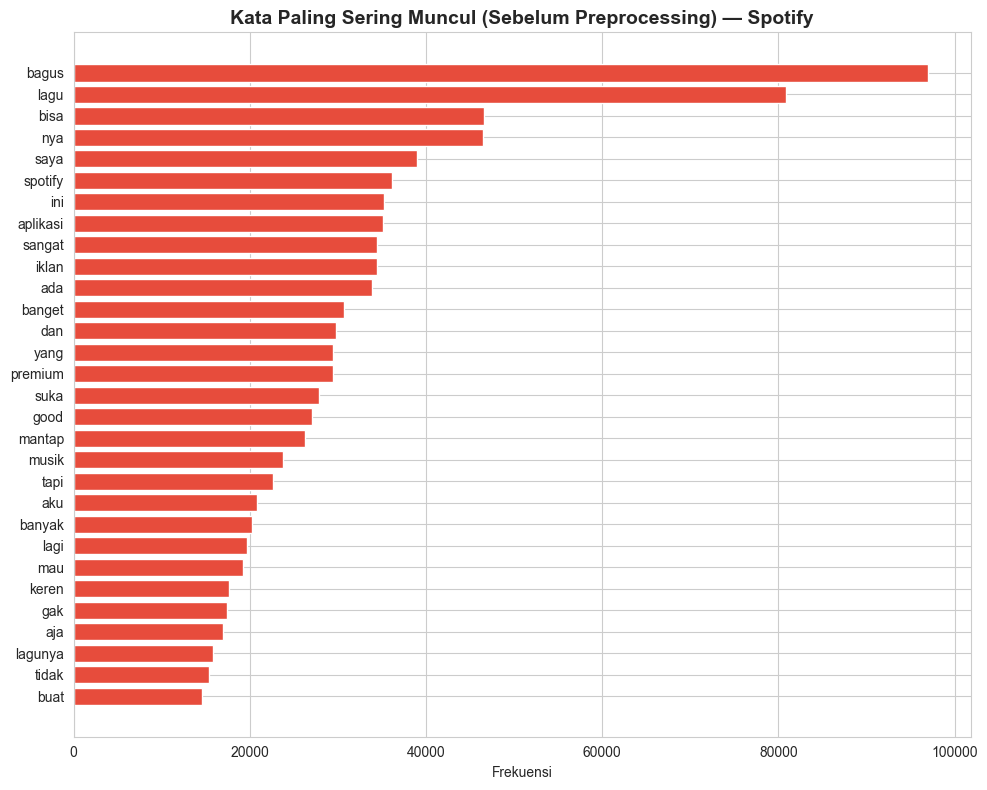

In [46]:
all_text = ' '.join(df_spotify['content'].dropna()).lower()
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text)
word_counts_raw = Counter(words).most_common(30)
labels_raw, values_raw = zip(*word_counts_raw)

plt.figure(figsize=(10, 8))
plt.barh(labels_raw, values_raw, color='#e74c3c', edgecolor='white')
plt.title('Kata Paling Sering Muncul (Sebelum Preprocessing) — Spotify',
          fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Deteksi dan Filter Bahasa Indonesia

In [48]:
from multiprocessing import Pool, cpu_count

def deteksi_bahasa(teks):
    try:
        if isinstance(teks, str) and len(teks.strip()) > 5:
            bahasa, _ = langid.classify(teks[:100])
            return bahasa
        return 'unknown'
    except:
        return 'error'

def proses_per_bagian(df_bagian):
    df_bagian = df_bagian.copy()
    df_bagian['bahasa_terdeteksi'] = df_bagian['content'].apply(deteksi_bahasa)
    return df_bagian

def proses_paralel(df, fungsi):
    if df.empty:
        return df.copy()

    jumlah_core = cpu_count()
    idx_terbagi = np.array_split(df.index.to_numpy(), jumlah_core)
    df_terbagi = [df.loc[idx].copy() for idx in idx_terbagi if len(idx) > 0]

    with Pool(processes=min(jumlah_core, len(df_terbagi))) as pool:
        hasil = pd.concat(pool.map(fungsi, df_terbagi), axis=0)

    return hasil.sort_index()

print(f'⏳ Mendeteksi bahasa dari {len(df_spotify):,} baris...')
df_spotify = proses_paralel(df_spotify, proses_per_bagian)

# Filter hanya ulasan bahasa Indonesia
df_spotify = df_spotify[df_spotify['bahasa_terdeteksi'] == 'id'].reset_index(drop=True)

print(f'✅ Selesai! Ulasan bahasa Indonesia tersisa: {len(df_spotify):,} baris')
display(df_spotify[['content', 'bahasa_terdeteksi']].head())

⏳ Mendeteksi bahasa dari 482,741 baris...
✅ Selesai! Ulasan bahasa Indonesia tersisa: 185,716 baris


,content,bahasa_terdeteksi
0,terima kasih Spotify sudah menyediakan lagu_la...,id
1,udah cape nge download lagu mslah jadi premium,id
2,aku suka aplikasi nya,id
3,tolong ilangin iklan nya dong sering tiba-tiba...,id
4,bintang 1,id


## Ekstraksi Polaritas & Subjektivitas

In [49]:
# Polaritas dan subjektivitas dihitung sebagai fitur kuantitatif pendahuluan sebelum pemodelan menggunakan TextBlob

df_spotify['sentiment_polarity']   = df_spotify['content'].astype(str).apply(
    lambda x: TextBlob(x).polarity)
df_spotify['sentiment_subjective'] = df_spotify['content'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity)

# Labeling berdasarkan skor rating
df_spotify['sentiment_rating'] = df_spotify['score'].apply(
    lambda x: 'Positif' if x > 3 else ('Netral' if x == 3 else 'Negatif'))

df_spotify.loc[:, ['content', 'score',
                    'sentiment_polarity', 'sentiment_subjective',
                    'sentiment_rating']].head()

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,terima kasih Spotify sudah menyediakan lagu_la...,5,0.0,0.0,Positif
1,udah cape nge download lagu mslah jadi premium,1,0.0,0.0,Negatif
2,aku suka aplikasi nya,5,0.0,0.0,Positif
3,tolong ilangin iklan nya dong sering tiba-tiba...,4,0.0,0.0,Positif
4,bintang 1,5,0.0,0.0,Positif


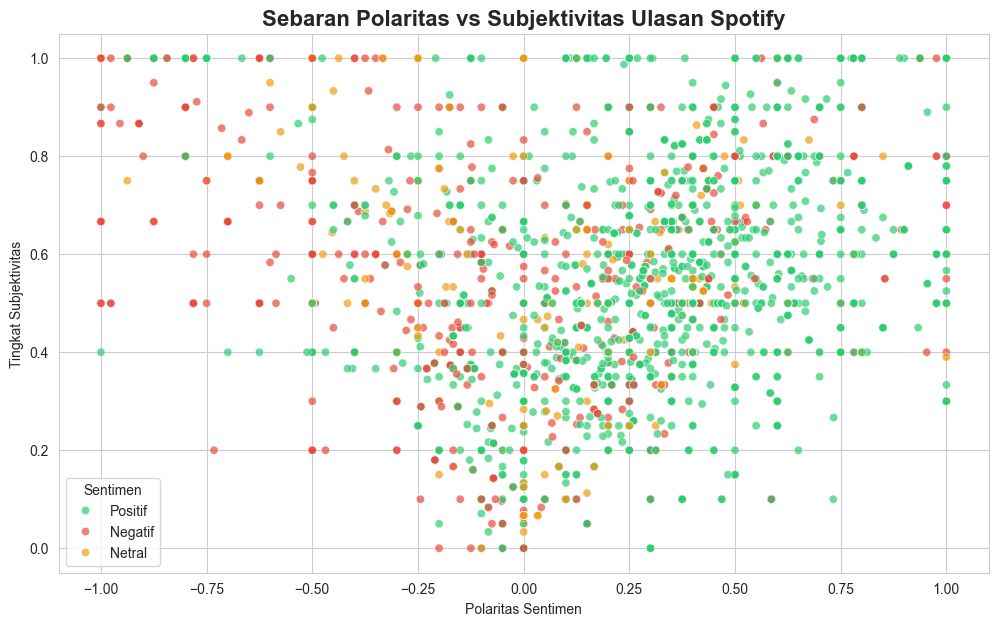

In [50]:
# Scatter plot polarity vs subjectivity
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=df_spotify['sentiment_polarity'],
    y=df_spotify['sentiment_subjective'],
    hue=df_spotify['sentiment_rating'],
    palette={'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c'},
    edgecolor='white', alpha=0.7
)
plt.title('Sebaran Polaritas vs Subjektivitas Ulasan Spotify',
          fontsize=16, fontweight='bold')
plt.xlabel('Polaritas Sentimen')
plt.ylabel('Tingkat Subjektivitas')
plt.legend(title='Sentimen')
plt.show()

## Tokenisasi

In [51]:
# Setiap kalimat ulasan dipecah menjadi satuan kata tunggal (token)

def lakukan_tokenisasi(teks):
    return word_tokenize(str(teks))

df_spotify['token_awal'] = df_spotify['content'].apply(lakukan_tokenisasi)

display(df_spotify[['content', 'token_awal']].head())

,content,token_awal
0,terima kasih Spotify sudah menyediakan lagu_la...,"[terima, kasih, Spotify, sudah, menyediakan, l..."
1,udah cape nge download lagu mslah jadi premium,"[udah, cape, nge, download, lagu, mslah, jadi,..."
2,aku suka aplikasi nya,"[aku, suka, aplikasi, nya]"
3,tolong ilangin iklan nya dong sering tiba-tiba...,"[tolong, ilangin, iklan, nya, dong, sering, ti..."
4,bintang 1,"[bintang, 1]"


## Lowercasing

In [52]:
def ubah_ke_huruf_kecil(tokens):
    return [t.lower() for t in tokens]

df_spotify['token_lowercase'] = df_spotify['token_awal'].apply(ubah_ke_huruf_kecil)

display(df_spotify[['token_awal', 'token_lowercase']].head())

,token_awal,token_lowercase
0,"[terima, kasih, Spotify, sudah, menyediakan, l...","[terima, kasih, spotify, sudah, menyediakan, l..."
1,"[udah, cape, nge, download, lagu, mslah, jadi,...","[udah, cape, nge, download, lagu, mslah, jadi,..."
2,"[aku, suka, aplikasi, nya]","[aku, suka, aplikasi, nya]"
3,"[tolong, ilangin, iklan, nya, dong, sering, ti...","[tolong, ilangin, iklan, nya, dong, sering, ti..."
4,"[bintang, 1]","[bintang, 1]"


## Normalisasi Slang

In [53]:
kamus_slang = {
    # Negasi
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'ngga': 'tidak',
    'nggak': 'tidak', 'ndak': 'tidak', 'kagak': 'tidak', 'kaga': 'tidak',
    'gaada': 'tidak ada', 'gabisa': 'tidak bisa', 'gamau': 'tidak mau',
    'gajelas': 'tidak jelas', 'gajel': 'tidak jelas',

    # Kata umum & Penghubung
    'yg': 'yang', 'udh': 'sudah', 'udah': 'sudah', 'tp': 'tapi',
    'kalo': 'kalau', 'klo': 'kalau', 'jd': 'jadi', 'krn': 'karena',
    'utk': 'untuk', 'jg': 'juga', 'dr': 'dari', 'dgn': 'dengan',
    'sm': 'sama', 'aja': 'saja', 'aj': 'saja', 'dah': 'sudah',
    'sdh': 'sudah', 'tapi': 'tapi', 'biar': 'supaya', 'kayak': 'seperti',
    'kyk': 'seperti', 'kek': 'seperti', 'bgt': 'sekali', 'bngt': 'sekali',
    'banget': 'sekali', 'emang': 'memang', 'emg': 'memang',

    # Kata ganti & Sapaan
    'sy': 'saya', 'gue': 'saya', 'gw': 'saya', 'aku': 'saya',
    'lu': 'kamu', 'lo': 'kamu', 'elu': 'kamu', 'ente': 'kamu',
    'min': 'admin', 'minn': 'admin', 'kak': 'kakak', 'kk': 'kakak',

    # Istilah Spotify & Aplikasi
    'apk': 'aplikasi', 'hp': 'handphone', 'pake': 'pakai',
    'pakek': 'pakai', 'dl': 'download', 'unduh': 'download',
    'pl': 'playlist', 'subs': 'langganan', 'prem': 'premium',
    'preman': 'premium', 'ads': 'iklan', 'iklanya': 'iklannya',
    'lyric': 'lirik', 'lyrics': 'lirik', 'song': 'lagu',
    'update': 'perbarui', 'updet': 'perbarui', 'instal': 'pasang',

    # Keluhan Teknis & Emosi
    'lemot': 'lambat', 'lelet': 'lambat', 'eror': 'error',
    'error': 'error', 'bug': 'gangguan', 'ngebug': 'gangguan',
    'lag': 'macet', 'ngelag': 'macet', 'fc': 'force close',
    'keluar': 'keluar sendiri', 'ribet': 'rumit', 'nyesel': 'menyesal',
    'kecewa': 'kecewa', 'parah': 'buruk', 'jelek': 'buruk',
    'mantap': 'bagus', 'mantul': 'bagus', 'oke': 'bagus',
    'sip': 'bagus', 'gud': 'bagus', 'good': 'bagus',

    # Waktu & Lainnya
    'skrg': 'sekarang', 'skrng': 'sekarang', 'trs': 'terus',
    'trus': 'terus', 'mulu': 'terus menerus', 'sering': 'sering',
    'sll': 'selalu', 'dulu': 'dulu', 'dlu': 'dulu',
    'pas': 'ketika', 'kapan': 'kapan', 'recomended': 'rekomendasi',
}

def normalisasi_slang(tokens):
    return [kamus_slang.get(token, token) for token in tokens]

df_spotify['token_normalisasi'] = df_spotify['token_lowercase'].apply(normalisasi_slang)

display(df_spotify[['token_lowercase', 'token_normalisasi']].head())

,token_lowercase,token_normalisasi
0,"[terima, kasih, spotify, sudah, menyediakan, l...","[terima, kasih, spotify, sudah, menyediakan, l..."
1,"[udah, cape, nge, download, lagu, mslah, jadi,...","[sudah, cape, nge, download, lagu, mslah, jadi..."
2,"[aku, suka, aplikasi, nya]","[saya, suka, aplikasi, nya]"
3,"[tolong, ilangin, iklan, nya, dong, sering, ti...","[tolong, ilangin, iklan, nya, dong, sering, ti..."
4,"[bintang, 1]","[bintang, 1]"


## Stopword Removal

In [54]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_sastrawi = set(factory.get_stop_words())

# Kata negasi & emosi yang WAJIB dipertahankan (jangan dihapus)
# 'banget' dipertahankan karena sering memperkuat sentimen (intensifier)
# 'gak'/'tidak' dipertahankan agar tidak mengubah makna
kata_penting = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'kurang', 'gak', 'ga', 'nggak'}

# Custom stopwords domain Spotify (Kata yang sering muncul tapi netral/noise)
custom_stopwords_id = [
    'aplikasi', 'spotify', 'music', 'lagu', 'playlist', 'artist',
    'album', 'play', 'pause', 'skip', 'like', 'dislike',
    'follow', 'unfollow', 'share', 'comment', 'review',
    'update', 'new', 'latest', 'trending', 'popular'
]

# Tambahkan angka dan simbol ke custom stopwords secara otomatis
simbol_angka = [str(i) for i in range(10)] + ['&', '.', ',', '-', '!', '?', '(', ')']
custom_stopwords_id.extend(simbol_angka)

# Gabungkan: Sastrawi + Custom - Kata Penting
stopwords_final = (stopword_sastrawi.union(set(custom_stopwords_id))) - kata_penting

def hapus_stopwords(tokens):
    return [
        token for token in tokens
        # Token harus tidak ada di list stopword DAN panjangnya lebih dari 2
        # (kecuali untuk kata penting seperti 'ga')
        if (token not in stopwords_final and len(token) > 2) or token in kata_penting
    ]

# Jalankan pembersihan
df_spotify['token_bersih'] = df_spotify['token_normalisasi'].apply(hapus_stopwords)

# Statistik
total_sebelum = df_spotify['token_normalisasi'].apply(len).sum()
total_sesudah = df_spotify['token_bersih'].apply(len).sum()
reduksi = (total_sebelum - total_sesudah) / total_sebelum * 100

print(f'Total token sebelum  : {total_sebelum:,}')
print(f'Total token sesudah  : {total_sesudah:,}')
print(f'Persentase reduksi   : {reduksi:.2f}%')
print(f'Total stopwords aktif: {len(stopwords_final)}')

display(df_spotify[['token_normalisasi', 'token_bersih']].head())

Total token sebelum  : 2,236,513
Total token sesudah  : 992,153
Persentase reduksi   : 55.64%
Total stopwords aktif: 843


,token_normalisasi,token_bersih
0,"[terima, kasih, spotify, sudah, menyediakan, l...","[terima, kasih, menyediakan, lagu_lagu]"
1,"[sudah, cape, nge, download, lagu, mslah, jadi...","[cape, nge, download, mslah, premium]"
2,"[saya, suka, aplikasi, nya]",[suka]
3,"[tolong, ilangin, iklan, nya, dong, sering, ti...","[tolong, ilangin, iklan, muncul, ngedj, galau,..."
4,"[bintang, 1]",[bintang]


## Stemming

In [55]:
stemmer_factory = StemmerFactory()
stemmer_id = stemmer_factory.create_stemmer()

def lakukan_stemming(tokens):
    kalimat = ' '.join(tokens)
    return stemmer_id.stem(kalimat).split()

df_spotify['token_stemmed'] = df_spotify['token_bersih'].apply(lakukan_stemming)

# Statistik perubahan
total_sebelum_stem = df_spotify['token_bersih'].apply(len).sum()
total_sesudah_stem = df_spotify['token_stemmed'].apply(len).sum()

print(f'Total token sebelum stemming: {total_sebelum_stem:,}')
print(f'Total token sesudah stemming: {total_sesudah_stem:,}')

display(df_spotify[['token_bersih', 'token_stemmed']].head())

Total token sebelum stemming: 992,153
Total token sesudah stemming: 991,341


,token_bersih,token_stemmed
0,"[terima, kasih, menyediakan, lagu_lagu]","[terima, kasih, sedia, lagu, lagu]"
1,"[cape, nge, download, mslah, premium]","[cape, nge, download, mslah, premium]"
2,[suka],[suka]
3,"[tolong, ilangin, iklan, muncul, ngedj, galau,...","[tolong, ilangin, iklan, muncul, ngedj, galau,..."
4,[bintang],[bintang]


## Hapus Tanda Baca

In [56]:
def hapus_tanda_baca(tokens):
    return [
        token for token in tokens
        if token not in string.punctuation and token.strip() != ''
    ]

df_spotify['token_tanpa_punctuation'] = df_spotify['token_stemmed'].apply(hapus_tanda_baca)

display(df_spotify[['token_stemmed', 'token_tanpa_punctuation']].head())

,token_stemmed,token_tanpa_punctuation
0,"[terima, kasih, sedia, lagu, lagu]","[terima, kasih, sedia, lagu, lagu]"
1,"[cape, nge, download, mslah, premium]","[cape, nge, download, mslah, premium]"
2,[suka],[suka]
3,"[tolong, ilangin, iklan, muncul, ngedj, galau,...","[tolong, ilangin, iklan, muncul, ngedj, galau,..."
4,[bintang],[bintang]


## Hapus Rare Words

In [57]:
# Kata dengan frekuensi sangat rendah (< 5 kali) dibuang karena tidak memiliki kekuatan statistik

frekuensi_semua_kata = Counter(
    kata for tokens in df_spotify['token_tanpa_punctuation']
    for kata in tokens
)

ambang_batas = 5
kata_langka = {kata for kata, jumlah in frekuensi_semua_kata.items() if jumlah < ambang_batas}

def hapus_kata_langka(tokens):
    return [kata for kata in tokens if kata not in kata_langka]

df_spotify['token_final'] = df_spotify['token_tanpa_punctuation'].apply(hapus_kata_langka)

df_perubahan = df_spotify[
    df_spotify['token_tanpa_punctuation'].astype(str) != df_spotify['token_final'].astype(str)
]

print(f'Jumlah kata langka ditemukan  : {len(kata_langka):,}')
print(f'Jumlah ulasan terdampak       : {len(df_perubahan):,}')
display(df_perubahan[['token_tanpa_punctuation', 'token_final']].head())

Jumlah kata langka ditemukan  : 33,643
Jumlah ulasan terdampak       : 33,035


,token_tanpa_punctuation,token_final
3,"[tolong, ilangin, iklan, muncul, ngedj, galau,...","[tolong, ilangin, iklan, muncul, galau, kesel]"
13,"[asli, sih, tidak, bintang, bintang, nol, nge,...","[asli, sih, tidak, bintang, bintang, nol, nge,..."
23,"[buruk, main, potong, saldo, batal, langgan, c...","[buruk, main, potong, saldo, batal, langgan, c..."
32,"[dosa, tamak, harga, 59, 99k, premium, 79, 99k]","[dosa, tamak, harga, 59, premium, 79]"
35,"[aplikasi, bagus, saran, opsi, gratis, hari, 1...","[aplikasi, bagus, saran, opsi, gratis, hari, m..."


## Hapus Baris Kosong

In [58]:
baris_kosong = df_spotify[df_spotify['token_final'].apply(lambda x: len(x) == 0)]
print(f'Jumlah baris kosong ditemukan: {len(baris_kosong):,}')

df_spotify = df_spotify[df_spotify['token_final'].apply(lambda x: len(x) > 0)].copy()
print(f'Jumlah ulasan clear          : {len(df_spotify):,}')

display(df_spotify[['content', 'token_final']].head())

Jumlah baris kosong ditemukan: 3,272
Jumlah ulasan clear          : 182,444


,content,token_final
0,terima kasih Spotify sudah menyediakan lagu_la...,"[terima, kasih, sedia, lagu, lagu]"
1,udah cape nge download lagu mslah jadi premium,"[cape, nge, download, mslah, premium]"
2,aku suka aplikasi nya,[suka]
3,tolong ilangin iklan nya dong sering tiba-tiba...,"[tolong, ilangin, iklan, muncul, galau, kesel]"
4,bintang 1,[bintang]


## Rekonstruksi Teks & Final Labeling

In [59]:
df_spotify['content_bersih'] = df_spotify['token_final'].apply(lambda x: ' '.join(x))

# Hitung ulang polarity dari teks yang sudah bersih
df_spotify['sentiment_polarity']   = df_spotify['content_bersih'].astype(str).apply(
    lambda x: TextBlob(x).polarity)
df_spotify['sentiment_subjective'] = df_spotify['content_bersih'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity)
df_spotify['sentiment_rating'] = df_spotify['score'].apply(
    lambda x: 'Positif' if x > 3 else ('Netral' if x == 3 else 'Negatif'))

display(df_spotify[['content_bersih', 'score',
                    'sentiment_polarity', 'sentiment_subjective',
                    'sentiment_rating']].head())

,content_bersih,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,terima kasih sedia lagu lagu,5,0.0,0.0,Positif
1,cape nge download mslah premium,1,0.0,0.0,Negatif
2,suka,5,0.0,0.0,Positif
3,tolong ilangin iklan muncul galau kesel,4,0.0,0.0,Positif
4,bintang,5,0.0,0.0,Positif


# Dataset Final Preparation

## Dataset Final

In [60]:
df_bersih = df_spotify.copy()

kolom_buang = [
    'token_awal', 'token_lowercase', 'token_normalisasi',
    'token_bersih', 'token_stemmed', 'token_tanpa_punctuation',
    'token_final'
]
df_bersih = df_bersih.drop(columns=kolom_buang)

display(df_bersih.head())
df_bersih.info()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bahasa_terdeteksi,sentiment_polarity,sentiment_subjective,sentiment_rating,content_bersih
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,terima kasih Spotify sudah menyediakan lagu_la...,5,0,Null,2026-04-07 13:41:34,Tidak Ada Balasan,Tidak Ada Balasan,Null,id,0.0,0.0,Positif,terima kasih sedia lagu lagu
1,4315cfa0-bd46-4cff-bb7d-9b774dc9b74d,udah cape nge download lagu mslah jadi premium,1,0,9.1.32.2083,2026-04-07 12:43:56,Tidak Ada Balasan,Tidak Ada Balasan,9.1.32.2083,id,0.0,0.0,Negatif,cape nge download mslah premium
2,a496f842-ecfc-42d5-981a-83fed84b873e,aku suka aplikasi nya,5,0,9.1.30.1993,2026-04-07 12:37:32,Tidak Ada Balasan,Tidak Ada Balasan,9.1.30.1993,id,0.0,0.0,Positif,suka
3,90c02b81-7bee-4046-8a49-497aef4c62f2,tolong ilangin iklan nya dong sering tiba-tiba...,4,0,9.1.34.2060,2026-04-07 12:14:50,Tidak Ada Balasan,Tidak Ada Balasan,9.1.34.2060,id,0.0,0.0,Positif,tolong ilangin iklan muncul galau kesel
4,f44842b2-0969-442e-b0f4-f7fc83184b37,bintang 1,5,0,Null,2026-04-07 12:05:08,Tidak Ada Balasan,Tidak Ada Balasan,Null,id,0.0,0.0,Positif,bintang


<class 'pandas.DataFrame'>
Index: 182444 entries, 0 to 185715
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              182444 non-null  str           
 1   content               182444 non-null  str           
 2   score                 182444 non-null  int64         
 3   thumbsUpCount         182444 non-null  int64         
 4   reviewCreatedVersion  182444 non-null  str           
 5   at                    182444 non-null  datetime64[us]
 6   replyContent          182444 non-null  str           
 7   repliedAt             182444 non-null  str           
 8   appVersion            182444 non-null  str           
 9   bahasa_terdeteksi     182444 non-null  str           
 10  sentiment_polarity    182444 non-null  float64       
 11  sentiment_subjective  182444 non-null  float64       
 12  sentiment_rating      182444 non-null  str           
 13  content_bersih 

## Perbandingan Frekuensi Data

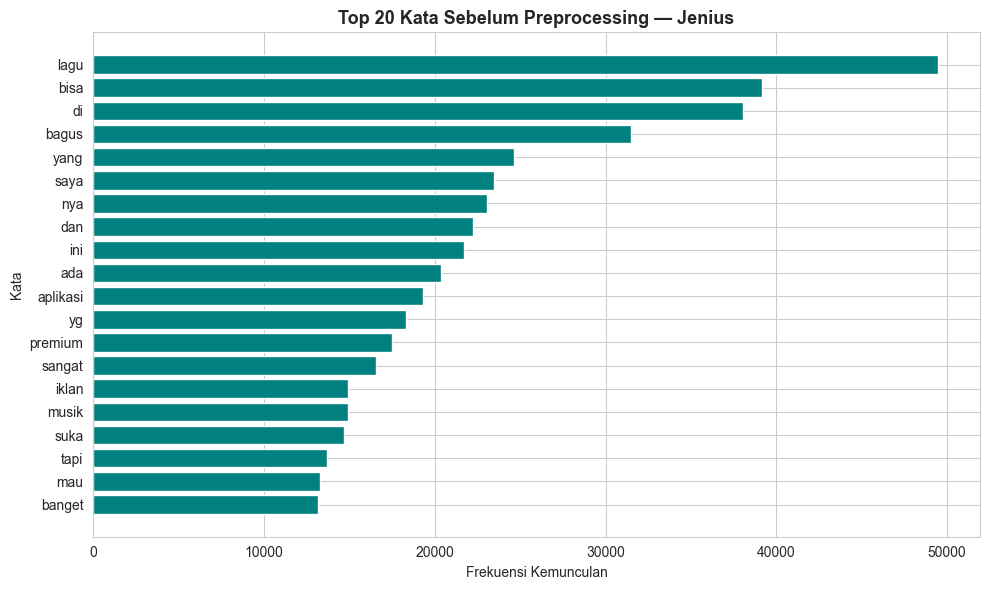

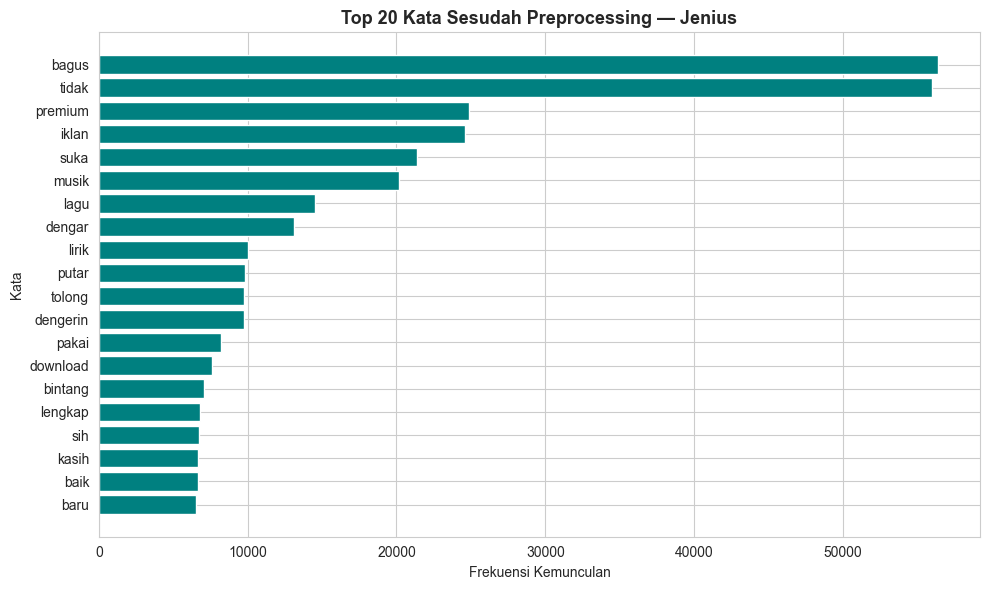

In [61]:
def tampilkan_frekuensi(seri_teks, judul):
    semua_kata = ' '.join(seri_teks.dropna().astype(str)).split()
    frekuensi = Counter(semua_kata)
    top_20 = frekuensi.most_common(20)
    df_top = pd.DataFrame(top_20, columns=['Kata', 'Frekuensi'])

    plt.figure(figsize=(10, 6))
    plt.barh(df_top['Kata'][::-1], df_top['Frekuensi'][::-1], color='teal')
    plt.xlabel('Frekuensi Kemunculan')
    plt.ylabel('Kata')
    plt.title(judul, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Sebelum preprocessing
tampilkan_frekuensi(df_spotify['content'],
                    'Top 20 Kata Sebelum Preprocessing — Jenius')

# Sesudah preprocessing
tampilkan_frekuensi(df_bersih['content_bersih'],
                    'Top 20 Kata Sesudah Preprocessing — Jenius')

## Simpan Dataset Final

In [62]:
output_path = '../out/cleandata_spotify.csv'
df_bersih.to_csv(output_path, index=False, encoding='utf-8')

print(f'✅ Data berhasil disimpan ke: {output_path}')
print(f'   Jumlah baris : {len(df_bersih):,}')
print(f'   Jumlah kolom : {df_bersih.shape[1]}')

✅ Data berhasil disimpan ke: ../out/cleandata_spotify.csv
   Jumlah baris : 182,444
   Jumlah kolom : 14
